In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib as mpl

import scipy
import numpy as np
import pandas as pd
import datetime as dt

from pathlib import Path
import soundfile as sf
from tqdm import tqdm
from sklearn.cluster import KMeans
import scipy.signal as signal
import scipy.special as special

from matplotlib.patches import Circle
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

In [2]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
from pipeline import pipeline
from cfg import get_config

import bout.clustering as clstr
import bout.assembly as bt

In [3]:
from models.bat_call_detector.model_detector import BatCallDetector

In [4]:
SAMPLERATE = 250000
NUM_CHANNELS = 8
BYTES_PER_SAMPLE = 2 #int16

In [5]:
C = 343 # m/s speed of sound in air
FS = 250000
SNR_CALC_LENGTH = 0.050
SNR_OFFSET_BEFORE_CALL = 0.015
TIME_PAD_FOR_ECHO = 0.002
CORR_LENGTH = 0.025
SELECTED_CHANNEL_FOR_REF = 7
NUM_CHANNELS_TOTAL = 8
FILE_DURATION = 600
HOUR_TAG = 'hour_0'
ZMAG_REF_TO_6 = 29.125
ZMAG_REF_TO_7 = 31.6875
XMAG_REF_TO_1 = 17.7
YMAG_REF_TO_6 = 21
YMAG_REF_TO_1 = 37.5
A_LOCS_MAT = np.array([[-XMAG_REF_TO_1, -YMAG_REF_TO_1, ZMAG_REF_TO_7],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, ZMAG_REF_TO_7],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_6, -ZMAG_REF_TO_6],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_6, -ZMAG_REF_TO_6],
                    [0, 0, ZMAG_REF_TO_7],
                    [0, 0, 0]])

In [6]:
import UBNA_localize_process_GCC__20250505 as localize

In [7]:
def plot_snr_and_mic_labels(x_axis, y_axis):
    for i in np.linspace(0, x_axis.shape[0]-1, 11).astype(int):
        scale = 0.3
        t_x, t_y = x_axis[i]+scale, y_axis[i]+scale
        plt.text(x=t_x, y=t_y, s=f'det{round(i, 1)}', fontsize=14)

In [8]:
%matplotlib inline

file_dir = Path('/Volumes/Elements/UBNA_array_tests2025/mic_array_test_20250501/inUBNA/array')
site_key = 'Carp'
freq_key = ''

In [9]:
start_stop_file = (file_dir / 'Start_Stop_Times.txt')
with open(start_stop_file, "r", encoding="utf-8") as file:
    content = file.read()
    print(content)
    
start_stop_arr = content.split('\n')
start_of_session = start_stop_arr[0]
FILE_DATETIME = dt.datetime.strptime(start_of_session, 'Start time: %H:%M:%S %m/%d/%y UTC')

Start time: 03:30:14 05/02/25 UTC
Stop time: 04:38:26 05/02/25 UTC



In [10]:
file_offset = 1800
FILE_TIME_TAG = f'{int(file_offset)}to{int(file_offset+FILE_DURATION)}'
dir_name = f'{HOUR_TAG}_{FILE_TIME_TAG}'
write_dir = file_dir / dir_name
channel_dets = localize.get_dets_observed_from_all_channels(file_dir, file_offset)
channel_dets = channel_dets[channel_dets['KMEANS_CLASSES']=='LF'].copy()
channel_dets.sort_values(by='start_time', inplace=True)
channel_dets.reset_index(drop=True, inplace=True)
channel_dets['freq_group'] = channel_dets['KMEANS_CLASSES']
channel_dets['call_start_time'] = pd.to_timedelta(channel_dets['start_time']*1e9) + FILE_DATETIME
channel_dets['cycle_ref_time'] = pd.to_timedelta(channel_dets['start_time']*1e9) + FILE_DATETIME
channel_dets['call_end_time'] = pd.to_timedelta(channel_dets['end_time']*1e9) + FILE_DATETIME
channel_dets['start_time_wrt_ref'] = channel_dets['start_time']
channel_dets['end_time_wrt_ref'] = channel_dets['end_time']

In [11]:
# removed_overlaps = localize.remove_overlapping_events(channel_dets, OVERLAP_TIME_THRESHOLD=12e-3)
# removed_overlaps.to_csv(f'ARRAY_20250501_{dir_name}_OVERLAPS_REMOVED.csv', sep=',', index=False)

In [12]:
removed_overlaps = pd.read_csv(f'ARRAY_20250501_{dir_name}_OVERLAPS_REMOVED.csv')
snr_thresh_dets = removed_overlaps[removed_overlaps['SNR']>=20].copy()

In [13]:
# data_params = dict()
# data_params['site_tag'] = site_key
# data_params['type_tag'] = freq_key
# data_params['detector_tag'] = 'bd2'
# data_params['assembly_type'] = 'kmeans'
# file_paths = dict()
# file_paths["SITE_folder"] = f'/Users/adityakrishna/duty-cycle-investigation/data/2022_detector_summaries/{data_params["site_tag"]}'
# file_paths["detector_TYPE_SITE_YEAR"] = f'{data_params["detector_tag"]}__{data_params["type_tag"]}{data_params["site_tag"]}_2022_{data_params["assembly_type"]}'
# location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', index_col=0, low_memory=False)
# bout_params = bt.get_bout_params_from_location(location_df, data_params)

# tagged_dets = bt.classify_bouts_in_detector_preds_for_freqgroups(snr_thresh_dets, bout_params)
# bout_metrics = bt.construct_bout_metrics_from_location_df_for_freqgroups(tagged_dets)
# bout_metrics

In [14]:
COLOR_MAP_FOR_TRAJ = {0:cm.Blues, 1:cm.Reds, 2:cm.Greens}
MIC_MARKER_THICKNESS = 2
POINT_SIZE = 75

In [15]:
def plot_three_plane_trajectories(ax1, ax2, ax3, dets, good_bucket, bucket, mic_locs, color_ind):
    ax1.plot(good_bucket[0,:], good_bucket[1,:], alpha=0.4, linewidth=2, color='k')
    ax1.scatter(x=mic_locs[:,0], y=mic_locs[:,1], zorder=3, s=POINT_SIZE, 
                marker='x', linewidths=MIC_MARKER_THICKNESS, color='k')

    ax2.plot(good_bucket[1,:], good_bucket[2,:], alpha=0.4, linewidth=2, color='k')
    ax2.scatter(x=mic_locs[:,1], y=mic_locs[:,2], zorder=3, s=POINT_SIZE, 
                marker='x', linewidths=MIC_MARKER_THICKNESS, color='k')

    ax3.plot(good_bucket[0,:], good_bucket[2,:], alpha=0.4, linewidth=2, color='k')
    ax3.scatter(x=mic_locs[:,0], y=mic_locs[:,2], zorder=3, s=POINT_SIZE, 
                marker='x', linewidths=MIC_MARKER_THICKNESS, color='k')

    norm = plt.Normalize(vmin=min(dets['start_time']), vmax=max(dets['start_time']))
    for i in range(good_bucket.shape[1]):
        det = dets.iloc[i]
        line_color = COLOR_MAP_FOR_TRAJ[color_ind](norm(det['start_time']))
        ax1.scatter(bucket[0,i], bucket[1,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)
        ax2.scatter(bucket[1,i], bucket[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)
        ax3.scatter(bucket[0,i], bucket[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)

In [16]:
def plot_colored_dets_over_audio(audio_features, spec_features, plot_dets):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    file_offset = audio_features['file_offset']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 24})
    plt.title(f"Spectrogram of {audio_features['plot_title']}", fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')

    ax = plt.gca()
    for i, row in plot_dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - (start+file_offset))*(fs/2), row['low_freq']/(fs/2)), 
                        (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                        linewidth=2, edgecolor=localize.FREQ_COLORS[row['KMEANS_CLASSES']], facecolor='none', alpha=0.8)
        plt.axvline(x=(row['peak_frequency_time_SPECTROGRAM'] - start)*(fs/2), color='w', linestyle='dashed')
        plt.text(x=(row['start_time'] - (start+file_offset))*(fs/2), y=row['low_freq']/(fs/2), s=f"{round(row['SNR'], 2)}dB"
                 , color='w', fontsize=8, fontweight='bold')
        ax.add_patch(rect)

    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace((start+file_offset), (start+file_offset)+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.show()

def plot_audio_bout(write_file, selected_channel_for_ref, start, length, file_offset, subset1, subset2):
    recorded_audio = sf.SoundFile(write_file)
    recorded_audio.seek(int(FS*start))
    audio_seg = recorded_audio.read(int(FS*length))
    highpassed_audio_seg = localize.highpass_audio_signal(audio_seg, FS, 20000)

    print(f'Currently at {write_file}')
    audio_features = dict()
    audio_features['figsize'] = (15, 3)
    audio_features['file_path'] = write_file
    audio_features['audio_seg'] = highpassed_audio_seg
    audio_features['sample_rate'] = FS
    audio_features['start'] = start
    audio_features['file_offset'] = file_offset
    audio_features['duration'] = length

    spec_features = dict()
    spec_features['NFFT'] = 256 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
    spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
    spec_features['vmin'] = -90
    spec_features['vmax'] = 0

    audio_features['plot_title'] = f"{audio_features['file_path'].stem} (mic {selected_channel_for_ref+1})"
    plot_colored_dets_over_audio(audio_features, spec_features, pd.DataFrame())
    plot_colored_dets_over_audio(audio_features, spec_features, subset1)
    plot_colored_dets_over_audio(audio_features, spec_features, subset2)

Currently at /Volumes/Elements/UBNA_array_tests2025/mic_array_test_20250501/inUBNA/array/hour_0_1800to2400/hour_0_channel7_1800to2400.WAV


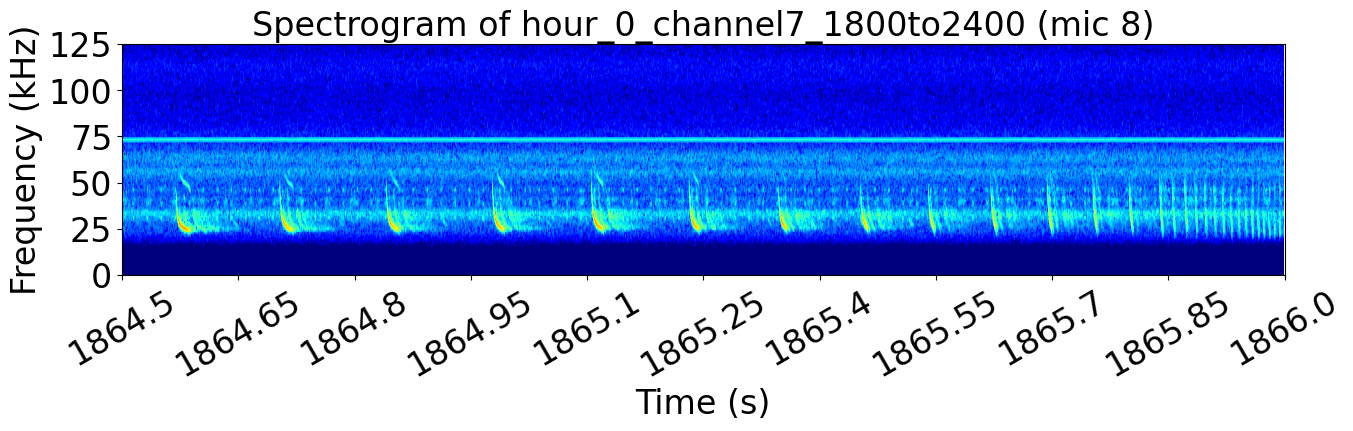

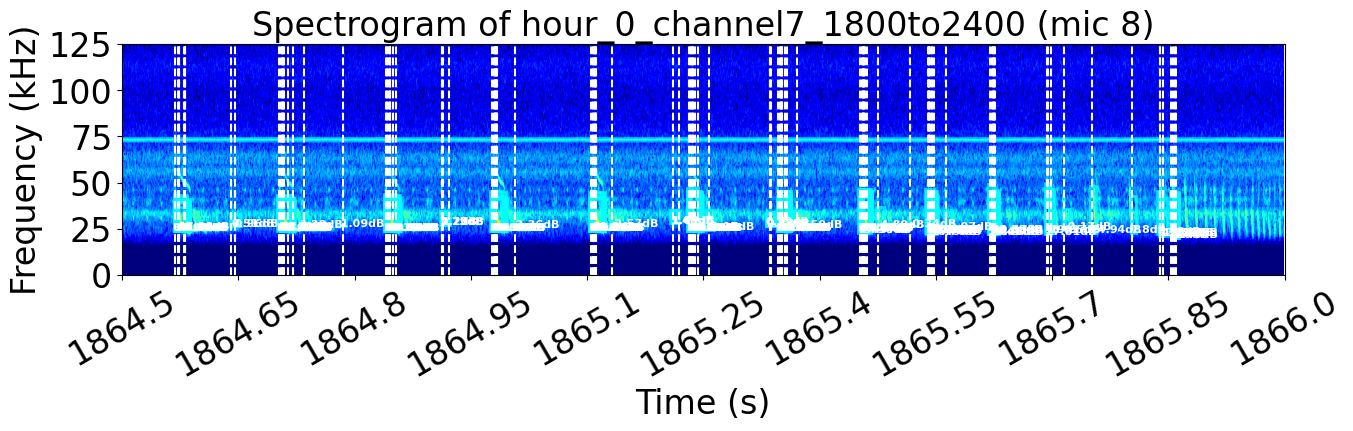

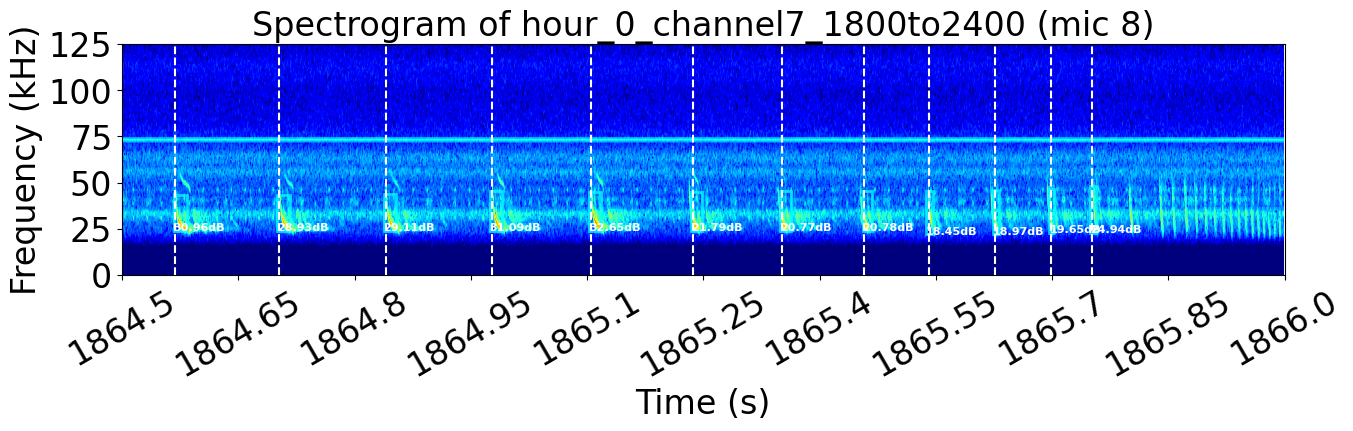

In [17]:
%matplotlib inline

write_file = write_dir / f'{HOUR_TAG}_channel{SELECTED_CHANNEL_FOR_REF}_{FILE_TIME_TAG}.WAV'

start = 64.5
length = 1.5
plot_channel_dets = channel_dets.loc[(channel_dets['start_time']>=(file_offset+start))&(channel_dets['end_time']<=(file_offset+start+length))]
plot_dets = removed_overlaps.loc[(removed_overlaps['start_time']>=(file_offset+start))&(removed_overlaps['end_time']<=(file_offset+start+length))]

set_for_tdoa = plot_dets[plot_dets['SNR']>=15].reset_index(drop=True).copy()
plot_audio_bout(write_file, SELECTED_CHANNEL_FOR_REF, start, length, file_offset, plot_channel_dets, set_for_tdoa)

In [18]:
import ipywidgets as widgets

In [19]:
ASSUMED_BAT_SPEED = 4 # m/s

In [20]:
ASSUMED_BAT_IPI = 0.1 # secs (100ms)

In [21]:
distance_covered_between_pulse = ASSUMED_BAT_SPEED * ASSUMED_BAT_IPI
f'{distance_covered_between_pulse} meters'

'0.4 meters'

In [28]:
GRID_SIZE = 25
CIRCLE_RADIUS = 10
SOUND_SPEED_AIR = 343
TIME_RECEIVED_AT_RN = 1
RCVR_COLORS = ['red', 'limegreen', 'blue', 'mediumpurple', 'slategray']
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=RCVR_COLORS)
COLOR_CYCLE = plt.rcParams['axes.prop_cycle'].by_key()['color']
BAT_INIT_DIST = 10

In [29]:
def simulate_N_receivers(angle_deg, N, spacing):
    rN_x = np.zeros(N)
    rN_y = np.linspace(-spacing * (N - 1) / 2, spacing * (N - 1) / 2, N)
    if N==1:
        trace_offsets = np.array([0])
    else:
        trace_offsets = 2.5e-4 * np.linspace(-0.1, 0.1, N)

    sampling_rate = 10000
    t = np.linspace(0, 4, sampling_rate*4)
    signal = scipy.signal.unit_impulse(t.size, idx=TIME_RECEIVED_AT_RN*sampling_rate) * 1000
    plot_duration = 0.1
    signal_duration = 1

    angle_degrees = np.arange(-90, 91)
    angle_idx = np.where(np.isclose(angle_degrees, angle_deg, atol=1e-2))[0][0]
    angle_radians = np.radians(angle_degrees)
    circle_x_arr = CIRCLE_RADIUS * np.cos(angle_radians)
    circle_y_arr = CIRCLE_RADIUS * np.sin(angle_radians)
    circle_x = circle_x_arr[angle_idx]
    circle_y = circle_y_arr[angle_idx]

    dist_from_source_to_r_n_arr = np.sqrt((circle_x_arr[None, :] - rN_x[:, None]) ** 2 + (circle_y_arr[None, :] - rN_y[:, None]) ** 2)

    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_degrees = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * sampling_rate))
    rn_indices = ((TIME_RECEIVED_AT_RN - time_to_rn_array) * sampling_rate).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_degrees = np.take_along_axis(receive_signaln_for_degrees, rn_indices, axis=0)

    fig = plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size':12})
    gs = gridspec.GridSpec(1, 3, width_ratios=[4, 4, 2], wspace=0.3) 
    gs_signals = gridspec.GridSpecFromSubplotSpec(2, 1, height_ratios=[2,1], subplot_spec=gs[0, 1], hspace=0.8)
    map_ax = plt.subplot(gs[0, 0])
    map_ax.scatter(circle_x, circle_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")

    received_ax = plt.subplot(gs_signals[0])
    map_ax.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
    received_ax.plot(1000*(np.tile(signal_duration_samples / sampling_rate, (N, 1)).T), chunk_of_received_signaln_in_window_degrees[:,:,angle_idx]+trace_offsets)
    marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
    line_handles = [Line2D([0], [0], label=f'rcvr #{i+1}', color=COLOR_CYCLE[i]) for i in range(N)]

    map_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_xlabel("X (meters)")
    map_ax.set_ylabel("Y (meters)")
    map_ax.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax.legend(handles=marker_handles, ncol=2, loc='upper right')

    received_ax.set_xlabel("Time (ms)")
    received_ax.set_ylabel("Amplitude")
    received_ax.set_title("Received voltage signals")
    received_ax.grid(which='both')
    received_ax.set_yticks([], [])
    received_ax.set_xlim(0, 1000*plot_duration)
    received_ax.set_ylim(-1e-4, 1e-4)
    received_ax.legend(handles=line_handles, ncol=2, loc='lower right')

    summed_signal_degrees = np.sum(chunk_of_received_signaln_in_window_degrees, axis=1)
    vrms_summed = np.sqrt(np.mean(np.square(summed_signal_degrees), axis=0))
    vrms_summed_dB = 20*np.log10(vrms_summed)
    vrms_summed_dB_norm = vrms_summed_dB - vrms_summed_dB.max()

    summed_signal = summed_signal_degrees[:, angle_idx]
    vrms_summed_fixed = vrms_summed[angle_idx]
    vrms_summed_fixed_dB = 20*np.log10(vrms_summed_fixed)
    vrms_summed_fixed_dB_norm = vrms_summed_fixed_dB - vrms_summed_dB.max()

    summed_ax = plt.subplot(gs_signals[1])
    summed_ax.plot(1000*(signal_duration_samples / sampling_rate), summed_signal, 'k')
    summed_ax.set_xlabel("Time (ms)")
    summed_ax.set_ylabel("Amplitude")
    summed_ax.set_title("Summed voltage signal")
    summed_ax.set_yticks([], [])
    summed_ax.grid(which='both')
    summed_ax.set_xlim(0, 1000*plot_duration)
    summed_ax.set_ylim(-5e-5, 5e-5)

    plt.show()

angle_slider = widgets.IntSlider(
    value=0, min=-90, max=90, step=1, description="Angle (°)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

N_slider = widgets.IntSlider(
    value=0, min=1, max=5, step=1, description="# receivers", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="300px")
)

spacing_slider = widgets.FloatSlider(
    value=1, min=0, max=5, step=0.01, description="Spacing (m)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, angle_deg=angle_slider, N=N_slider, spacing=spacing_slider)
display(interactive_plot)

interactive(children=(IntSlider(value=0, description='Angle (°)', layout=Layout(width='1000px'), max=90, min=-…

In [30]:
TIMESTEPS = np.arange(0, ((BAT_INIT_DIST / 2)/ASSUMED_BAT_SPEED) + ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
def simulate_N_receivers(time_step, N, spacing):
    rN_x = np.zeros(N)
    rN_y = np.linspace(-spacing * (N - 1) / 2, spacing * (N - 1) / 2, N)
    if N==1:
        trace_offsets = np.array([0])
    else:
        trace_offsets = 2.5e-4 * np.linspace(-0.1, 0.1, N)

    sampling_rate = FS
    t = np.linspace(0, 4, sampling_rate*4)
    signal = scipy.signal.unit_impulse(t.size, idx=TIME_RECEIVED_AT_RN*sampling_rate) * 1000
    plot_duration = 0.02
    signal_duration = 0.1

    time_idx = np.where(np.isclose(TIMESTEPS, time_step, atol=1e-2))[0][0]
    x_arr = ASSUMED_BAT_SPEED * (TIMESTEPS)
    y_arr = ASSUMED_BAT_SPEED * (TIMESTEPS) - (BAT_INIT_DIST / 2)
    pos_x = x_arr[time_idx]
    pos_y = y_arr[time_idx]

    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2)
    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_timestep = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * sampling_rate))
    rn_indices = ((TIME_RECEIVED_AT_RN - time_to_rn_array) * sampling_rate).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

    fig = plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size':12})
    gs = gridspec.GridSpec(1, 3, width_ratios=[4, 4, 2], wspace=0.3) 
    gs_signals = gridspec.GridSpecFromSubplotSpec(2, 1, height_ratios=[2,1], subplot_spec=gs[0, 1], hspace=0.8)
    map_ax = plt.subplot(gs[0, 0])
    map_ax.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")

    received_ax = plt.subplot(gs_signals[0])
    map_ax.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
    received_ax.plot(1000*(np.tile(signal_duration_samples / sampling_rate, (N, 1)).T), chunk_of_received_signaln_in_window_timestep[:,:,time_idx]+trace_offsets)
    marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
    line_handles = [Line2D([0], [0], label=f'rcvr #{i+1}', color=COLOR_CYCLE[i]) for i in range(N)]

    map_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_xlabel("X (meters)")
    map_ax.set_ylabel("Y (meters)")
    map_ax.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax.legend(handles=marker_handles, ncol=2, loc='upper right')

    received_ax.set_xlabel("Time (ms)")
    received_ax.set_ylabel("Amplitude")
    received_ax.set_title("Received voltage signals")
    received_ax.grid(which='both')
    received_ax.set_yticks([], [])
    received_ax.set_xlim(0, 1000*plot_duration)
    received_ax.set_ylim(-1e-4, 1e-4)
    received_ax.legend(handles=line_handles, ncol=2, loc='lower right')

    summed_signal_timestep = np.sum(chunk_of_received_signaln_in_window_timestep, axis=1)
    vrms_summed = np.sqrt(np.mean(np.square(summed_signal_timestep), axis=0))
    vrms_summed_dB = 20*np.log10(vrms_summed)
    vrms_summed_dB_norm = vrms_summed_dB - vrms_summed_dB.max()

    summed_signal = summed_signal_timestep[:, time_idx]
    vrms_summed_fixed = vrms_summed[time_idx]
    vrms_summed_fixed_dB = 20*np.log10(vrms_summed_fixed)
    vrms_summed_fixed_dB_norm = vrms_summed_fixed_dB - vrms_summed_dB.max()

    summed_ax = plt.subplot(gs_signals[1])
    summed_ax.plot(1000*(signal_duration_samples / sampling_rate), summed_signal, 'k')
    summed_ax.set_xlabel("Time (ms)")
    summed_ax.set_ylabel("Amplitude")
    summed_ax.set_title("Summed voltage signal")
    summed_ax.set_yticks([], [])
    summed_ax.grid(which='both')
    summed_ax.set_xlim(0, 1000*plot_duration)
    summed_ax.set_ylim(-5e-5, 5e-5)

    plt.show()

time_slider = widgets.FloatSlider(
    value=0, min=0, max=TIMESTEPS[-1], step=ASSUMED_BAT_IPI, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

N_slider = widgets.IntSlider(
    value=0, min=1, max=5, step=1, description="# receivers", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="300px")
)

spacing_slider = widgets.FloatSlider(
    value=1, min=0, max=5, step=0.01, description="Spacing (m)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, N=N_slider, spacing=spacing_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=0.0, description='Time (k)', layout=Layout(width='1000px'), max=1.3, s…

In [31]:
TIMESTEPS = np.arange(0, ((BAT_INIT_DIST / 2)/ASSUMED_BAT_SPEED) + ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
def simulate_N_receivers(time_step, spacing):
    N = 5
    rN_x = np.array([0, 0, 1, 0, 0]) * spacing
    rN_y = np.array([0, 1, 0, -1, 0]) * spacing
    rN_z = np.array([1, 0, 0, 0, -1]) * spacing
    trace_offsets = 2.5e-4 * np.linspace(-0.1, 0.1, N)

    sampling_rate = FS
    t = np.linspace(0, 4, sampling_rate*4)
    signal = scipy.signal.unit_impulse(t.size, idx=TIME_RECEIVED_AT_RN*sampling_rate) * 1000
    plot_duration = 0.02
    signal_duration = 0.1

    time_idx = np.where(np.isclose(TIMESTEPS, time_step, atol=1e-2))[0][0]
    x_arr = ASSUMED_BAT_SPEED * (TIMESTEPS)
    y_arr = ASSUMED_BAT_SPEED * (TIMESTEPS) - (BAT_INIT_DIST / 2)
    z_arr = np.zeros(TIMESTEPS.size)
    pos_x = x_arr[time_idx]
    pos_y = y_arr[time_idx]
    pos_z = 0

    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_timestep = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * sampling_rate))
    rn_indices = ((TIME_RECEIVED_AT_RN - time_to_rn_array) * sampling_rate).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

    fig = plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size':12})
    gs = gridspec.GridSpec(1, 3, width_ratios=[4, 4, 2], wspace=0.3) 
    gs_signals = gridspec.GridSpecFromSubplotSpec(2, 1, height_ratios=[2,1], subplot_spec=gs[0, 1], hspace=0.8)
    map_ax = plt.subplot(gs[0, 0])
    map_ax.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")

    received_ax = plt.subplot(gs_signals[0])
    map_ax.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
    received_ax.plot(1000*(np.tile(signal_duration_samples / sampling_rate, (N, 1)).T), chunk_of_received_signaln_in_window_timestep[:,:,time_idx]+trace_offsets)
    marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
    line_handles = [Line2D([0], [0], label=f'rcvr #{i+1}', color=COLOR_CYCLE[i]) for i in range(N)]

    map_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_xlabel("X (meters)")
    map_ax.set_ylabel("Y (meters)")
    map_ax.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax.legend(handles=marker_handles, ncol=2, loc='upper right')

    received_ax.set_xlabel("Time (ms)")
    received_ax.set_ylabel("Amplitude")
    received_ax.set_title("Received voltage signals")
    received_ax.grid(which='both')
    received_ax.set_yticks([], [])
    received_ax.set_xlim(0, 1000*plot_duration)
    received_ax.set_ylim(-1e-4, 1e-4)

    summed_signal_timestep = np.sum(chunk_of_received_signaln_in_window_timestep, axis=1)
    vrms_summed = np.sqrt(np.mean(np.square(summed_signal_timestep), axis=0))
    vrms_summed_dB = 20*np.log10(vrms_summed)
    vrms_summed_dB_norm = vrms_summed_dB - vrms_summed_dB.max()

    summed_signal = summed_signal_timestep[:, time_idx]
    vrms_summed_fixed = vrms_summed[time_idx]
    vrms_summed_fixed_dB = 20*np.log10(vrms_summed_fixed)
    vrms_summed_fixed_dB_norm = vrms_summed_fixed_dB - vrms_summed_dB.max()

    summed_ax = plt.subplot(gs_signals[1])
    summed_ax.plot(1000*(signal_duration_samples / sampling_rate), summed_signal, 'k')
    summed_ax.set_xlabel("Time (ms)")
    summed_ax.set_ylabel("Amplitude")
    summed_ax.set_title("Summed voltage signal")
    summed_ax.set_yticks([], [])
    summed_ax.grid(which='both')
    summed_ax.set_xlim(0, 1000*plot_duration)
    summed_ax.set_ylim(-5e-5, 5e-5)

    plt.show()

time_slider = widgets.FloatSlider(
    value=0, min=0, max=TIMESTEPS[-1], step=ASSUMED_BAT_IPI, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

N_slider = widgets.IntSlider(
    value=0, min=1, max=5, step=1, description="# receivers", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="300px")
)

spacing_slider = widgets.FloatSlider(
    value=1, min=0, max=5, step=0.01, description="Spacing (m)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, N=N_slider, spacing=spacing_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=0.0, description='Time (k)', layout=Layout(width='1000px'), max=1.3, s…

In [32]:
TIMESTEPS = np.arange(0, ((BAT_INIT_DIST / 2)/ASSUMED_BAT_SPEED) + ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
def simulate_N_receivers(time_step, spacing):
    N = 5
    rN_x = np.array([0, 0, 1, 0, 0]) * spacing
    rN_y = np.array([0, 1, 0, -1, 0]) * spacing
    rN_z = np.array([1, 0, 0, 0, -1]) * spacing
    trace_offsets = 2.5e-4 * np.linspace(-0.1, 0.1, N)

    sampling_rate = FS
    t = np.linspace(0, 4, sampling_rate*4)
    signal = scipy.signal.unit_impulse(t.size, idx=TIME_RECEIVED_AT_RN*sampling_rate) * 1000
    plot_duration = 0.02
    signal_duration = 0.1

    time_idx = np.where(np.isclose(TIMESTEPS, time_step, atol=1e-2))[0][0]
    x_arr = ASSUMED_BAT_SPEED * (TIMESTEPS)
    y_arr = ASSUMED_BAT_SPEED * (TIMESTEPS) - (BAT_INIT_DIST / 2)
    z_arr = np.zeros(TIMESTEPS.size)
    pos_x = x_arr[time_idx]
    pos_y = y_arr[time_idx]
    pos_z = 0

    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_timestep = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * sampling_rate))
    rn_indices = ((TIME_RECEIVED_AT_RN - time_to_rn_array) * sampling_rate).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

    fig = plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size':12})
    gs = gridspec.GridSpec(1, 3, width_ratios=[4, 4, 2], wspace=0.3) 
    gs_signals = gridspec.GridSpecFromSubplotSpec(2, 1, height_ratios=[2,1], subplot_spec=gs[0, 2], hspace=0.8)
    map_ax = plt.subplot(gs[0, 0])
    map_ax.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
    marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
    line_handles = [Line2D([0], [0], label=f'rcvr #{i+1}', color=COLOR_CYCLE[i]) for i in range(N)]

    map_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_xlabel("X (meters)")
    map_ax.set_ylabel("Y (meters)")
    map_ax.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax.legend(handles=marker_handles, ncol=2, loc='upper right')

    map_ax = plt.subplot(gs[0, 1], projection='3d')
    map_ax.scatter(pos_x, pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    received_ax = plt.subplot(gs_signals[0])
    map_ax.scatter(rN_x, rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])
    received_ax.plot(1000*(np.tile(signal_duration_samples / sampling_rate, (N, 1)).T), chunk_of_received_signaln_in_window_timestep[:,:,time_idx]+trace_offsets)
    map_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_zlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_xlabel("X (meters)")
    map_ax.set_ylabel("Y (meters)")
    map_ax.set_zlabel("Z (meters)")
    map_ax.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax.legend(handles=marker_handles, ncol=2, loc='upper right')

    received_ax.set_xlabel("Time (ms)")
    received_ax.set_ylabel("Amplitude")
    received_ax.set_title("Received voltage signals")
    received_ax.grid(which='both')
    received_ax.set_yticks([], [])
    received_ax.set_xlim(0, 1000*plot_duration)
    received_ax.set_ylim(-1e-4, 1e-4)

    summed_signal_timestep = np.sum(chunk_of_received_signaln_in_window_timestep, axis=1)
    vrms_summed = np.sqrt(np.mean(np.square(summed_signal_timestep), axis=0))
    vrms_summed_dB = 20*np.log10(vrms_summed)
    vrms_summed_dB_norm = vrms_summed_dB - vrms_summed_dB.max()

    summed_signal = summed_signal_timestep[:, time_idx]
    vrms_summed_fixed = vrms_summed[time_idx]
    vrms_summed_fixed_dB = 20*np.log10(vrms_summed_fixed)
    vrms_summed_fixed_dB_norm = vrms_summed_fixed_dB - vrms_summed_dB.max()

    summed_ax = plt.subplot(gs_signals[1])
    summed_ax.plot(1000*(signal_duration_samples / sampling_rate), summed_signal, 'k')
    summed_ax.set_xlabel("Time (ms)")
    summed_ax.set_ylabel("Amplitude")
    summed_ax.set_title("Summed voltage signal")
    summed_ax.set_yticks([], [])
    summed_ax.grid(which='both')
    summed_ax.set_xlim(0, 1000*plot_duration)
    summed_ax.set_ylim(-5e-5, 5e-5)

    plt.show()

time_slider = widgets.FloatSlider(
    value=0, min=0, max=TIMESTEPS[-1], step=ASSUMED_BAT_IPI, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

N_slider = widgets.IntSlider(
    value=0, min=1, max=5, step=1, description="# receivers", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="300px")
)

spacing_slider = widgets.FloatSlider(
    value=1, min=0, max=5, step=0.01, description="Spacing (m)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, N=N_slider, spacing=spacing_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=0.0, description='Time (k)', layout=Layout(width='1000px'), max=1.3, s…

In [33]:
spacing = 1
N = 5
time_step = 0

rN_x = np.array([0, 0, 1, 0, 0]) * spacing
rN_y = np.array([0, 1, 0, -1, 0]) * spacing
rN_z = np.array([1, 0, 0, 0, -1]) * spacing

sampling_rate = FS
t = np.linspace(0, 4, sampling_rate*4)
signal = scipy.signal.unit_impulse(t.size, idx=TIME_RECEIVED_AT_RN*sampling_rate) * 1000
plot_duration = 0.02
signal_duration = 0.1

time_idx = np.where(np.isclose(TIMESTEPS, time_step, atol=1e-2))[0][0]
x_arr = ASSUMED_BAT_SPEED * (TIMESTEPS)
y_arr = ASSUMED_BAT_SPEED * (TIMESTEPS) - (BAT_INIT_DIST / 2)
z_arr = np.zeros(TIMESTEPS.size)
pos_x = x_arr[time_idx]
pos_y = y_arr[time_idx]
pos_z = 0

dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
receive_signaln_for_timestep = signal[:, None, None]
signal_duration_samples = np.arange(int(signal_duration * sampling_rate))
rn_indices = ((TIME_RECEIVED_AT_RN - time_to_rn_array) * sampling_rate).astype(int) + signal_duration_samples[:, None, None]
chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)
summed_signal_timestep = np.sum(chunk_of_received_signaln_in_window_timestep, axis=1)
summed_signal = summed_signal_timestep[:, time_idx]

chunk_of_received_signaln_in_window_timestep.shape

(25000, 5, 14)

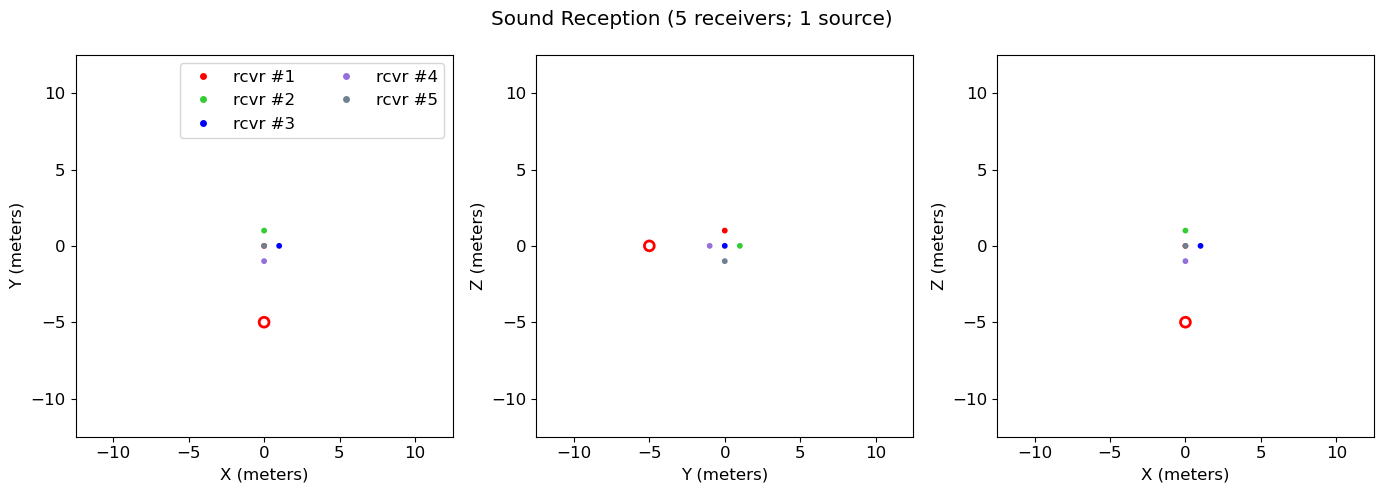

In [34]:
fig, map_ax = plt.subplots(1,3, figsize=(14,5))
top_ax = map_ax[0]
top_ax.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
top_ax.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
line_handles = [Line2D([0], [0], label=f'rcvr #{i+1}', color=COLOR_CYCLE[i]) for i in range(N)]

top_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
top_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
top_ax.set_xlabel("X (meters)")
top_ax.set_ylabel("Y (meters)")
fig.suptitle(f"Sound Reception ({int(N)} receivers; 1 source)")
top_ax.legend(handles=marker_handles, ncol=2, loc='upper right')

front_ax = map_ax[1]
front_ax.scatter(pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
front_ax.scatter(rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])

front_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
front_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
front_ax.set_xlabel("Y (meters)")
front_ax.set_ylabel("Z (meters)")
fig.suptitle(f"Sound Reception ({int(N)} receivers; 1 source)")

side_ax = map_ax[2]
side_ax.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
side_ax.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])

side_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
side_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
side_ax.set_xlabel("X (meters)")
side_ax.set_ylabel("Z (meters)")
fig.suptitle(f"Sound Reception ({int(N)} receivers; 1 source)")

fig.tight_layout()
plt.show()

In [72]:
%matplotlib inline

SELECTED_CHANNEL_FOR_REF = 2
microphones_used = np.array([1, 2, 3, 4, 5])
ind_of_selected_channel = np.where(microphones_used==(SELECTED_CHANNEL_FOR_REF+1))[0]
SELECTED_MIC_FOR_REF = microphones_used[ind_of_selected_channel]
non_ref_microphones_used = microphones_used[microphones_used!=SELECTED_MIC_FOR_REF]
num_good_channels = microphones_used.shape[0]
num_nonref_channels = num_good_channels-1

A_LOCS_MAT = np.array([rN_x,
                       rN_y,
                       rN_z]).T

A_locs_mat_wrt_ref_channel = A_LOCS_MAT
A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(non_ref_microphones_used-1)]

x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]

In [73]:
((dist_from_source_to_r_n_arr[:,:] / SOUND_SPEED_AIR)).T

array([[0.01486595, 0.01749271, 0.01486595, 0.01166181, 0.01486595],
       [0.01377377, 0.01636813, 0.01352468, 0.01056022, 0.01377377],
       [0.01280146, 0.01533871, 0.01225877, 0.00961657, 0.01280146],
       [0.01197821, 0.01442486, 0.01109405, 0.00888137, 0.01197821],
       [0.01133657, 0.0136498 , 0.0100657 , 0.00840945, 0.01133657],
       [0.01090862, 0.0130383 , 0.00921947, 0.00824614, 0.01090862],
       [0.01071999, 0.01261417, 0.00860923, 0.00840945, 0.01071999],
       [0.01078323, 0.01239667, 0.00828727, 0.00888137, 0.01078323],
       [0.01109405, 0.01239667, 0.00828727, 0.00961657, 0.01109405],
       [0.01163262, 0.01261417, 0.00860923, 0.01056022, 0.01163262],
       [0.01236921, 0.0130383 , 0.00921947, 0.01166181, 0.01236921],
       [0.01327091, 0.0136498 , 0.0100657 , 0.01288089, 0.01327091],
       [0.01430652, 0.01442486, 0.01109405, 0.0141872 , 0.01430652],
       [0.01544914, 0.01533871, 0.01225877, 0.01555879, 0.01544914]])

In [74]:
time_received_at_rn = ((np.argmax(chunk_of_received_signaln_in_window_timestep, axis=0)) / sampling_rate).T
time_received_at_rn

array([[0.014868, 0.017496, 0.014868, 0.011664, 0.014868],
       [0.013776, 0.016372, 0.013528, 0.010564, 0.013776],
       [0.012804, 0.01534 , 0.01226 , 0.00962 , 0.012804],
       [0.01198 , 0.014428, 0.011096, 0.008884, 0.01198 ],
       [0.01134 , 0.013652, 0.010068, 0.008412, 0.01134 ],
       [0.010912, 0.01304 , 0.00922 , 0.008248, 0.010912],
       [0.01072 , 0.012616, 0.008612, 0.008412, 0.01072 ],
       [0.010784, 0.0124  , 0.008288, 0.008884, 0.010784],
       [0.011096, 0.0124  , 0.008288, 0.00962 , 0.011096],
       [0.011636, 0.012616, 0.008612, 0.010564, 0.011636],
       [0.012372, 0.01304 , 0.00922 , 0.011664, 0.012372],
       [0.013272, 0.013652, 0.010068, 0.012884, 0.013272],
       [0.014308, 0.014428, 0.011096, 0.014188, 0.014308],
       [0.015452, 0.01534 , 0.01226 , 0.01556 , 0.015452]])

In [75]:
t_delay_ref_to_selected_channel = time_received_at_rn[:,ind_of_selected_channel]
time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, ind_of_selected_channel, axis=1)
measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)
measured_d_mics_to_ref

array([[ 0.      ,  0.901404, -1.098972,  0.      ],
       [ 0.085064,  0.975492, -1.016652,  0.085064],
       [ 0.186592,  1.05644 , -0.90552 ,  0.186592],
       [ 0.303212,  1.142876, -0.758716,  0.303212],
       [ 0.436296,  1.229312, -0.568008,  0.436296],
       [ 0.580356,  1.31026 , -0.333396,  0.580356],
       [ 0.723044,  1.373372, -0.0686  ,  0.723044],
       [ 0.856128,  1.410416,  0.204428,  0.856128],
       [ 0.963144,  1.410416,  0.456876,  0.963144],
       [ 1.037232,  1.373372,  0.669536,  1.037232],
       [ 1.081136,  1.31026 ,  0.838292,  1.081136],
       [ 1.098972,  1.229312,  0.965888,  1.098972],
       [ 1.101716,  1.142876,  1.060556,  1.101716],
       [ 1.094856,  1.05644 ,  1.1319  ,  1.094856]])

In [76]:
time_delay_mics_to_selected_ref_channel

array([[ 0.      ,  0.002628,  0.      , -0.003204,  0.      ],
       [ 0.000248,  0.002844,  0.      , -0.002964,  0.000248],
       [ 0.000544,  0.00308 ,  0.      , -0.00264 ,  0.000544],
       [ 0.000884,  0.003332,  0.      , -0.002212,  0.000884],
       [ 0.001272,  0.003584,  0.      , -0.001656,  0.001272],
       [ 0.001692,  0.00382 ,  0.      , -0.000972,  0.001692],
       [ 0.002108,  0.004004,  0.      , -0.0002  ,  0.002108],
       [ 0.002496,  0.004112,  0.      ,  0.000596,  0.002496],
       [ 0.002808,  0.004112,  0.      ,  0.001332,  0.002808],
       [ 0.003024,  0.004004,  0.      ,  0.001952,  0.003024],
       [ 0.003152,  0.00382 ,  0.      ,  0.002444,  0.003152],
       [ 0.003204,  0.003584,  0.      ,  0.002816,  0.003204],
       [ 0.003212,  0.003332,  0.      ,  0.003092,  0.003212],
       [ 0.003192,  0.00308 ,  0.      ,  0.0033  ,  0.003192]])

In [77]:
true_time_delay_mics_to_selected_ref_channel = ((dist_from_source_to_r_n_arr[:,:] / SOUND_SPEED_AIR) - (dist_from_source_to_r_n_arr[SELECTED_CHANNEL_FOR_REF,:] / SOUND_SPEED_AIR)).T
true_time_delay_mics_to_selected_ref_channel

array([[ 0.        ,  0.00262677,  0.        , -0.00320414,  0.        ],
       [ 0.00024909,  0.00284345,  0.        , -0.00296446,  0.00024909],
       [ 0.00054268,  0.00307994,  0.        , -0.0026422 ,  0.00054268],
       [ 0.00088416,  0.00333081,  0.        , -0.00221268,  0.00088416],
       [ 0.00127087,  0.0035841 ,  0.        , -0.00165625,  0.00127087],
       [ 0.00168915,  0.00381883,  0.        , -0.00097333,  0.00168915],
       [ 0.00211076,  0.00400495,  0.        , -0.00019978,  0.00211076],
       [ 0.00249596,  0.0041094 ,  0.        ,  0.0005941 ,  0.00249596],
       [ 0.00280678,  0.0041094 ,  0.        ,  0.0013293 ,  0.00280678],
       [ 0.00302339,  0.00400495,  0.        ,  0.00195099,  0.00302339],
       [ 0.00314975,  0.00381883,  0.        ,  0.00244234,  0.00314975],
       [ 0.00320521,  0.0035841 ,  0.        ,  0.00281519,  0.00320521],
       [ 0.00321247,  0.00333081,  0.        ,  0.00309315,  0.00321247],
       [ 0.00319037,  0.00307994,  0. 

In [78]:
true_d_mics_to_ref = np.delete(true_time_delay_mics_to_selected_ref_channel * SOUND_SPEED_AIR, ind_of_selected_channel, axis=1)
true_d_mics_to_ref

array([[ 0.        ,  0.90098049, -1.09901951,  0.        ],
       [ 0.08543932,  0.97530214, -1.01681135,  0.08543932],
       [ 0.18614047,  1.05641937, -0.90627471,  0.18614047],
       [ 0.3032682 ,  1.14246723, -0.75895028,  0.3032682 ],
       [ 0.43590912,  1.22934466, -0.56809428,  0.43590912],
       [ 0.57937973,  1.30985829, -0.33385054,  0.57937973],
       [ 0.72399065,  1.37369692, -0.06852359,  0.72399065],
       [ 0.85611432,  1.40952424,  0.20377516,  0.85611432],
       [ 0.96272544,  1.40952424,  0.45595042,  0.96272544],
       [ 1.03702286,  1.37369692,  0.66918944,  1.03702286],
       [ 1.08036303,  1.30985829,  0.83772234,  1.08036303],
       [ 1.09938737,  1.22934466,  0.96560911,  1.09938737],
       [ 1.10187814,  1.14246723,  1.06095051,  1.10187814],
       [ 1.09429731,  1.05641937,  1.13190642,  1.09429731]])

In [79]:
measured_d_mics_to_ref

array([[ 0.      ,  0.901404, -1.098972,  0.      ],
       [ 0.085064,  0.975492, -1.016652,  0.085064],
       [ 0.186592,  1.05644 , -0.90552 ,  0.186592],
       [ 0.303212,  1.142876, -0.758716,  0.303212],
       [ 0.436296,  1.229312, -0.568008,  0.436296],
       [ 0.580356,  1.31026 , -0.333396,  0.580356],
       [ 0.723044,  1.373372, -0.0686  ,  0.723044],
       [ 0.856128,  1.410416,  0.204428,  0.856128],
       [ 0.963144,  1.410416,  0.456876,  0.963144],
       [ 1.037232,  1.373372,  0.669536,  1.037232],
       [ 1.081136,  1.31026 ,  0.838292,  1.081136],
       [ 1.098972,  1.229312,  0.965888,  1.098972],
       [ 1.101716,  1.142876,  1.060556,  1.101716],
       [ 1.094856,  1.05644 ,  1.1319  ,  1.094856]])

In [80]:
is_close_matrix_custom = np.isclose(true_d_mics_to_ref, measured_d_mics_to_ref, atol=1e-4)
print("\nComparison with custom tolerance:")
print(is_close_matrix_custom)


Comparison with custom tolerance:
[[ True False  True  True]
 [False False False False]
 [False  True False False]
 [ True False False  True]
 [False  True  True False]
 [False False False False]
 [False False  True False]
 [ True False False  True]
 [False False False False]
 [False False False False]
 [False False False False]
 [False  True False False]
 [False False False False]
 [False  True  True False]]


In [185]:
idx = 11
measured_d_mics_to_ref[idx,:], true_d_mics_to_ref[idx,:]

(array([1.098972, 1.229312, 0.965888, 1.098972]),
 array([1.09938737, 1.22934466, 0.96560911, 1.09938737]))

In [213]:
dm0_column = true_d_mics_to_ref[idx,:].reshape((num_nonref_channels, 1))
A_mat = np.hstack(((A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF] - A_locs_mat_tdoa_meters), dm0_column))
A_mat

array([[ 1.        ,  0.        , -1.        ,  1.09938737],
       [ 1.        , -1.        ,  0.        ,  1.22934466],
       [ 1.        ,  1.        ,  0.        ,  0.96560911],
       [ 1.        ,  0.        ,  1.        ,  1.09938737]])

In [214]:
xm = A_locs_mat_tdoa_meters[:,0].reshape((num_nonref_channels, 1))
ym = A_locs_mat_tdoa_meters[:,1].reshape((num_nonref_channels, 1))
zm = A_locs_mat_tdoa_meters[:,2].reshape((num_nonref_channels, 1))
wm0 = ((dm0_column**2) - (xm**2) + (x0**2) - (ym**2) + (y0**2) - (zm**2) + (z0**2))/2
wm0

array([[0.6043263 ],
       [0.75564415],
       [0.46620047],
       [0.6043263 ]])

In [215]:
np.linalg.cond(A_mat)

2322.257553845157

In [216]:
xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
source_loc = xs.reshape((1,4))
source_loc

array([[ 4.4      , -0.6      ,  0.       , -3.4525353]])

In [217]:
lam = 1e-4
ATA = A_mat.T @ A_mat
ATb = A_mat.T @ wm0
ridge_solution = np.linalg.solve(ATA + lam * np.eye(A_mat.shape[1]), ATb)

source_loc = ridge_solution.reshape((1,4))
source_loc

array([[ 0.335252  , -0.1120187 ,  0.        ,  0.24795699]])

In [218]:
dm0_column = measured_d_mics_to_ref[idx,:].reshape((num_nonref_channels, 1))
A_mat = np.hstack(((A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF] - A_locs_mat_tdoa_meters), dm0_column))
A_mat

array([[ 1.      ,  0.      , -1.      ,  1.098972],
       [ 1.      , -1.      ,  0.      ,  1.229312],
       [ 1.      ,  1.      ,  0.      ,  0.965888],
       [ 1.      ,  0.      ,  1.      ,  1.098972]])

In [219]:
xm = A_locs_mat_tdoa_meters[:,0].reshape((num_nonref_channels, 1))
ym = A_locs_mat_tdoa_meters[:,1].reshape((num_nonref_channels, 1))
zm = A_locs_mat_tdoa_meters[:,2].reshape((num_nonref_channels, 1))
wm0 = ((dm0_column**2) - (xm**2) + (x0**2) - (ym**2) + (y0**2) - (zm**2) + (z0**2))/2
wm0

array([[0.60386973],
       [0.755604  ],
       [0.46646981],
       [0.60386973]])

In [220]:
np.linalg.cond(A_mat)

3233.1923960265162

In [221]:
xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
source_loc = xs.reshape((1,4))
source_loc

array([[ 6.34477857e+00, -8.32616091e-01,  5.55111512e-16,
        -5.22389000e+00]])

In [236]:
source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]), dtype=np.float64)
cond_a_vals = np.zeros(measured_d_mics_to_ref.shape[0], dtype=np.float64)
for i in range(measured_d_mics_to_ref.shape[0]):
    dm0_column = measured_d_mics_to_ref[i,:].reshape((num_nonref_channels, 1))
    A_mat = np.hstack(((A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF] - A_locs_mat_tdoa_meters), dm0_column))
        
    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]

    xm = A_locs_mat_tdoa_meters[:,0].reshape((num_nonref_channels, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((num_nonref_channels, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((num_nonref_channels, 1))

    wm0 = ((dm0_column**2) - (xm**2) + (x0**2) - (ym**2) + (y0**2) - (zm**2) + (z0**2))/2

    xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
    source_locs[:,i] = xs.reshape((1,4))
    cond_a_vals[i] = np.linalg.cond(A_mat)
source_locs

array([[ 1.04020038e-16,  4.00316118e-01,  8.00834942e-01,
         1.20413187e+00,  1.59548941e+00,  1.99031803e+00,
         2.42381382e+00,  2.84997031e+00,  3.26134414e+00,
         3.54103095e+00,  3.80753049e+00,  6.34477857e+00,
         2.73659558e-01,  5.37015919e-01],
       [-5.01500239e+00, -4.62470851e+00, -4.19277518e+00,
        -3.81433494e+00, -3.38740966e+00, -2.98137159e+00,
        -2.62662379e+00, -2.23606142e+00, -1.82994713e+00,
        -1.37837896e+00, -9.57031885e-01, -8.32616091e-01,
        -3.28813858e-02,  3.91347634e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         4.44089210e-16,  4.44089210e-16,  0.00000000e+00,
         0.00000000e+00,  4.44089210e-16,  4.44089210e-16,
         2.22044605e-16,  0.00000000e+00,  5.55111512e-16,
         1.11022302e-16,  7.63278329e-17],
       [-5.11284375e+00, -4.66352600e+00, -4.19860795e+00,
        -3.81964800e+00, -3.43874873e+00, -3.13929982e+00,
        -2.99071357e+00, -2.90084279e+00, -2.

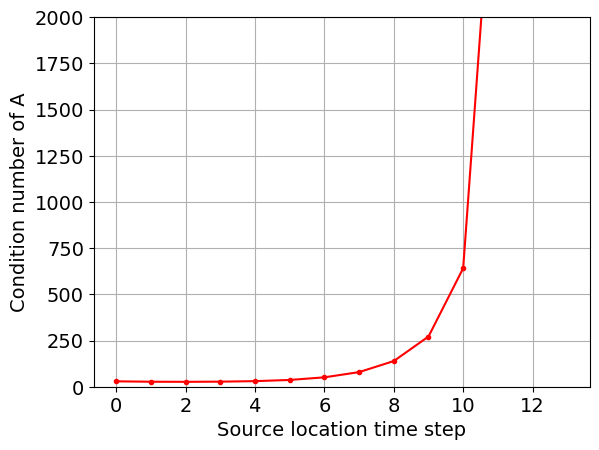

In [248]:
plt.plot(cond_a_vals, marker='.')
plt.grid(which='both')
plt.ylabel('Condition number of A')
plt.xlabel('Source location time step')
plt.ylim(0, 2000)
plt.show()

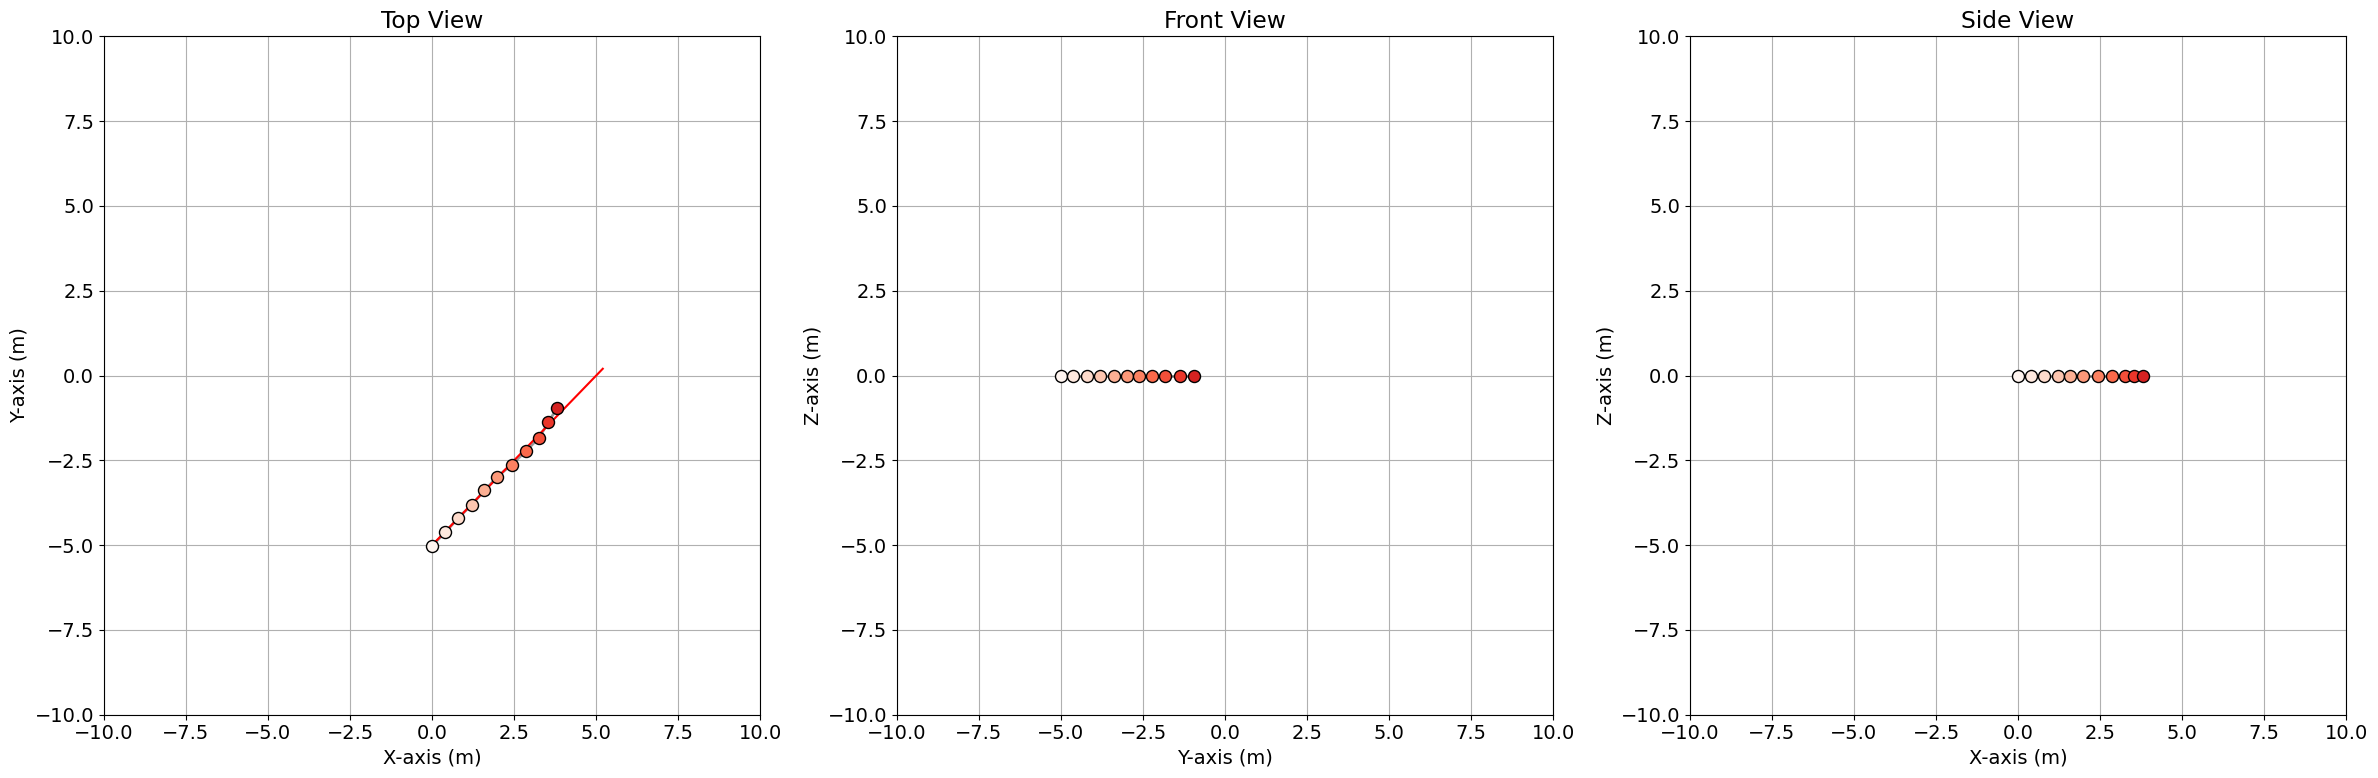

In [244]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
plt.rcParams.update({'font.size':14})
start = 0
end = np.where(cond_a_vals>1000)[0][0]

ax1.plot(source_locs[0,start:end], source_locs[1,start:end], alpha=0.4, linewidth=2, color='k')
ax1.plot(x_arr, y_arr, label='true position')

ax2.plot(source_locs[1,start:end], source_locs[2,start:end], alpha=0.4, linewidth=2, color='k')

ax3.plot(source_locs[0,start:end], source_locs[2,start:end], alpha=0.4, linewidth=2, color='k')

norm = plt.Normalize(vmin=0, vmax=source_locs.shape[1])
for i in range(start, end):
    line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
    ax1.scatter(source_locs[0,i], source_locs[1,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)
    ax2.scatter(source_locs[1,i], source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)
    ax3.scatter(source_locs[0,i], source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)

ax1.set_ylim(-10, 10)
ax1.set_xlim(-10, 10)
ax1.set_title('Top View')
ax1.grid(which='both')
ax1.set_xlabel('X-axis (m)')
ax1.set_ylabel('Y-axis (m)')

ax2.set_ylim(-10, 10)
ax2.set_xlim(-10, 10)
ax2.set_title('Front View')
ax2.grid(which='both')
ax2.set_xlabel('Y-axis (m)')
ax2.set_ylabel('Z-axis (m)')

ax3.set_ylim(-10, 10)
ax3.set_xlim(-10, 10)
ax3.set_title('Side View')
ax3.grid(which='both')
ax3.set_xlabel('X-axis (m)')
ax3.set_ylabel('Z-axis (m)')

plt.tight_layout()
plt.show()

### Below is now certified to work!!

In [245]:
source_locs = np.zeros((4, true_d_mics_to_ref.shape[0]), dtype=np.float64)
for i in range(true_d_mics_to_ref.shape[0]):
    dm0_column = true_d_mics_to_ref[i,:].reshape((num_nonref_channels, 1))
    A_mat = np.hstack(((A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF] - A_locs_mat_tdoa_meters), dm0_column))
        
    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]

    xm = A_locs_mat_tdoa_meters[:,0].reshape((num_nonref_channels, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((num_nonref_channels, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((num_nonref_channels, 1))

    wm0 = ((dm0_column**2) - (xm**2) + (x0**2) - (ym**2) + (y0**2) - (zm**2) + (z0**2))/2

    xs, residuals, rank, sing_vals = np.linalg.lstsq(A_mat, wm0, rcond=None)

    source_locs[:,i] = xs.reshape((1,4))
source_locs

array([[ 3.88149615e-16,  4.00000000e-01,  8.00000000e-01,
         1.20000000e+00,  1.60000000e+00,  2.00000000e+00,
         2.40000000e+00,  2.80000000e+00,  3.20000000e+00,
         3.60000000e+00,  4.00000000e+00,  4.40000000e+00,
         4.80000000e+00,  5.20000000e+00],
       [-5.00000000e+00, -4.60000000e+00, -4.20000000e+00,
        -3.80000000e+00, -3.40000000e+00, -3.00000000e+00,
        -2.60000000e+00, -2.20000000e+00, -1.80000000e+00,
        -1.40000000e+00, -1.00000000e+00, -6.00000000e-01,
        -2.00000000e-01,  2.00000000e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -4.44089210e-16,  0.00000000e+00,  8.88178420e-16,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         4.44089210e-16,  4.44089210e-16,  0.00000000e+00,
        -1.11022302e-16,  1.66533454e-16],
       [-5.09901951e+00, -4.63896540e+00, -4.20475921e+00,
        -3.80525952e+00, -3.45253530e+00, -3.16227766e+00,
        -2.95296461e+00, -2.84253408e+00, -2.

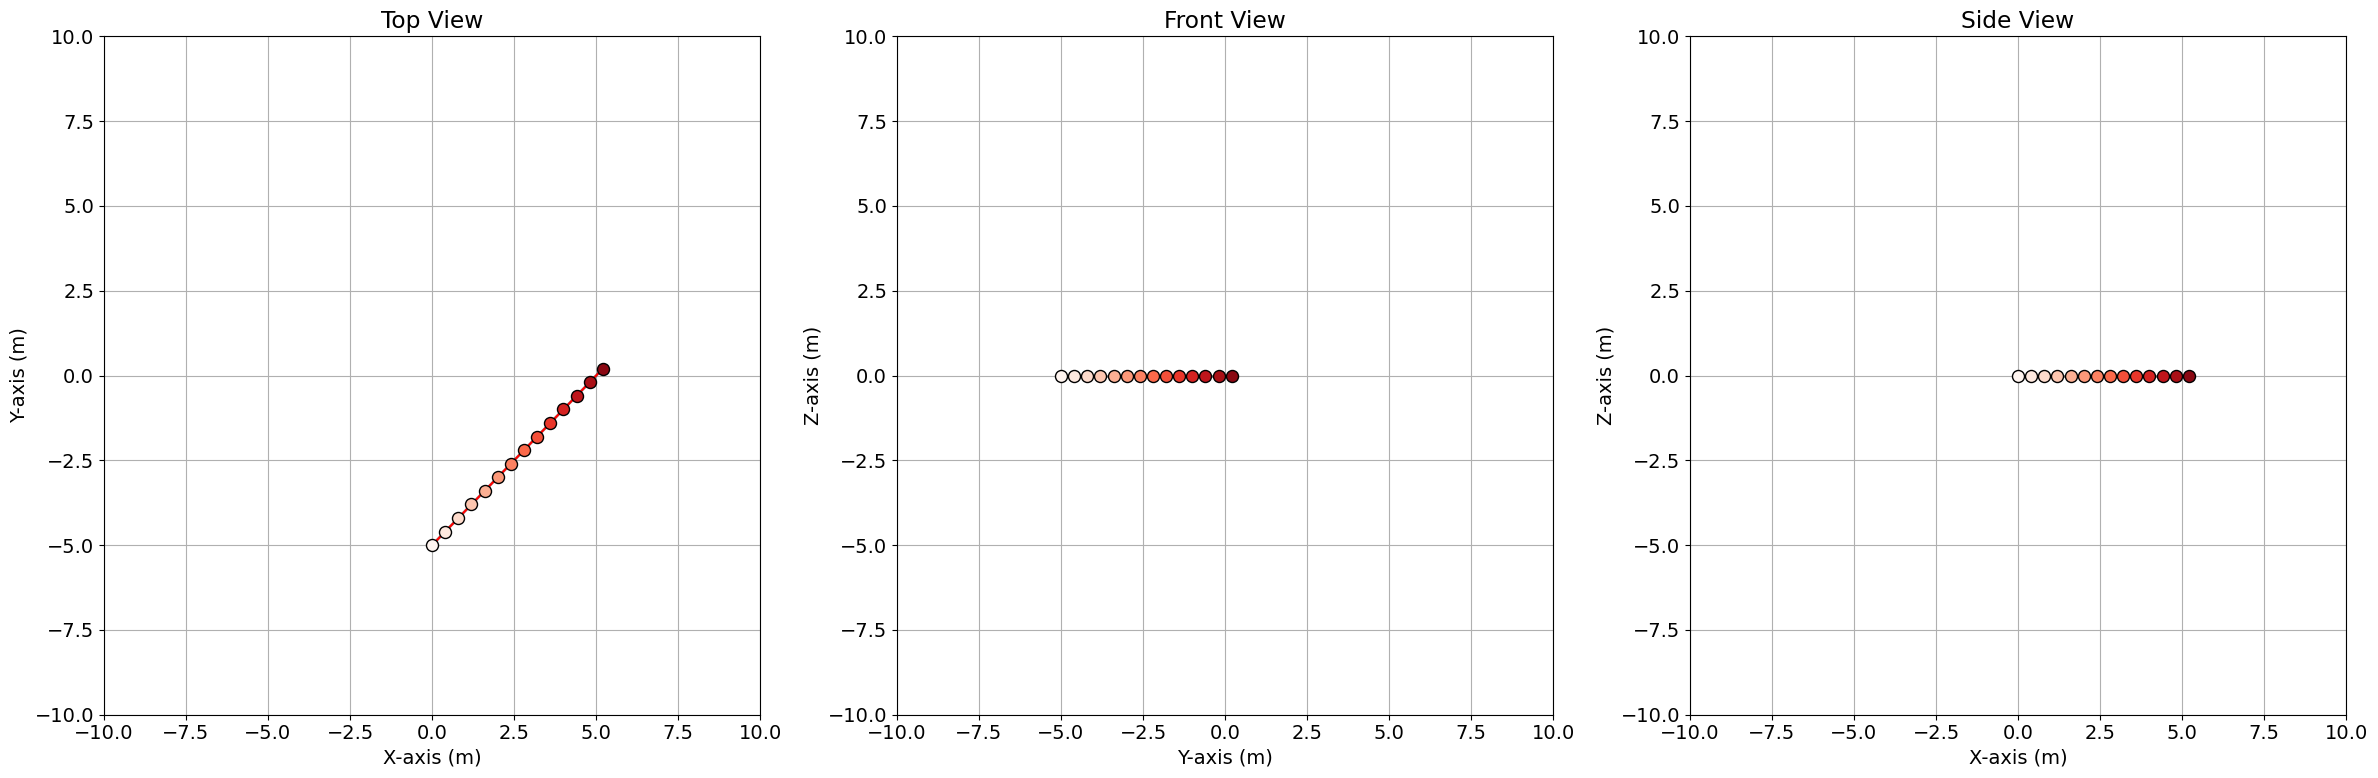

In [246]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
plt.rcParams.update({'font.size':14})

ax1.plot(source_locs[0,:], source_locs[1,:], alpha=0.4, linewidth=2, color='k')
ax1.plot(x_arr, y_arr, label='true position')

ax2.plot(source_locs[1,:], source_locs[2,:], alpha=0.4, linewidth=2, color='k')

ax3.plot(source_locs[0,:], source_locs[2,:], alpha=0.4, linewidth=2, color='k')

norm = plt.Normalize(vmin=0, vmax=source_locs.shape[1])
for i in range(source_locs.shape[1]):
    line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
    ax1.scatter(source_locs[0,i], source_locs[1,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)
    ax2.scatter(source_locs[1,i], source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)
    ax3.scatter(source_locs[0,i], source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)

ax1.set_ylim(-10, 10)
ax1.set_xlim(-10, 10)
ax1.set_title('Top View')
ax1.grid(which='both')
ax1.set_xlabel('X-axis (m)')
ax1.set_ylabel('Y-axis (m)')

ax2.set_ylim(-10, 10)
ax2.set_xlim(-10, 10)
ax2.set_title('Front View')
ax2.grid(which='both')
ax2.set_xlabel('Y-axis (m)')
ax2.set_ylabel('Z-axis (m)')

ax3.set_ylim(-10, 10)
ax3.set_xlim(-10, 10)
ax3.set_title('Side View')
ax3.grid(which='both')
ax3.set_xlabel('X-axis (m)')
ax3.set_ylabel('Z-axis (m)')

plt.tight_layout()
plt.show()